<a href="https://colab.research.google.com/github/CaesarGhazi/Flyrank/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CaesarGhazi/Flyrank/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Research question: What natural performance archetypes exist across FlyRank's content inventory, and can grouping content this way improve prioritization over a single-rule approach?

Decision this supports: which content a team should review first — protect it, fix a specific issue, or leave it alone — instead of treating every page identically. Acted on by content managers and SEO specialists. A wrong recommendation costs editor time on pages that didn't need it, or a missed real opportunity on a page that did.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Release: FlyRank internship warehouse (Hugging Face, gated).

Tables: fact_content_daily_performance (month=2026-03), joined to dim_content for content_type.

Date window: March 2026 — a mid-panel month, deliberately not the sealed final month (fact_content_daily_performance_sample.parquet, June 2026).

Excluded: AI-referral columns (confirmed <0.1% coverage this month), product action flags and *_date fields from dim_content (risk of encoding post-hoc decisions), and any April/June data (future-window leakage).

In [ ]:
# Setup — self-contained
import pandas as pd, numpy as np, os, json
from google.colab import userdata
HF_TOKEN = userdata.get("HF_TOKEN")
HF_BASE = "hf://datasets/FlyRank/internship-warehouse"
fact_cols = ["report_date","client_hash_id","content_hash_id","gsc_data_available","ga4_data_available",
             "gsc_impressions","gsc_clicks","gsc_avg_position","ga4_engaged_sessions"]
panel_daily = pd.read_parquet(f"{HF_BASE}/fact_content_daily_performance/month=2026-03/data_0.parquet",
                               columns=fact_cols, storage_options={"token": HF_TOKEN})
dim_content = pd.read_parquet(f"{HF_BASE}/dim_content.parquet",
                               columns=["client_hash_id","content_hash_id","content_type"],
                               storage_options={"token": HF_TOKEN})
for c in ["client_hash_id","content_hash_id"]:
    panel_daily[c] = panel_daily[c].astype("category"); dim_content[c] = dim_content[c].astype("category")
dim_content = dim_content.drop_duplicates(subset=["client_hash_id","content_hash_id"])
panel_daily = panel_daily.merge(dim_content, on=["client_hash_id","content_hash_id"], how="left")

content_level = panel_daily.groupby(["client_hash_id","content_hash_id"], observed=True).agg(
    gsc_impressions=("gsc_impressions","sum"), gsc_clicks=("gsc_clicks","sum"),
    gsc_avg_position=("gsc_avg_position","mean"), ga4_engaged_sessions=("ga4_engaged_sessions","sum"),
    content_type=("content_type","first")).reset_index()
content_level["ctr"] = content_level["gsc_clicks"] / content_level["gsc_impressions"].replace(0, np.nan)
print("Rows:", len(content_level), "| Date span:", panel_daily["report_date"].min(), "-", panel_daily["report_date"].max())


Rows: 331437 | Date span: 2026-03-01 - 2026-03-31


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Assumptions: content aggregated to client+content level over March; same-month features are enough to describe an archetype; features are standardized before clustering.

Features: gsc_impressions, gsc_clicks, gsc_avg_position, ga4_engaged_sessions — all observed, same-window metrics.

Label: none — this is unsupervised clustering. The baseline's reason_code (fix_ctr/monitor) is a defined rule, used only for comparison, never as a training target.

Baseline: rule-based CTR-vs-position score, one reason code, threshold set from a confirmed signal check.

Validation: grouped-by-client split, not random — avoids leaking client scale across train/test.

Leakage checks: confirmed no future-window/flag columns in the feature set; a deliberate leak test (April data) did not inflate the score — an honest negative result.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import silhouette_score

feature_cols = ["gsc_impressions","gsc_clicks","gsc_avg_position","ga4_engaged_sessions"]
groups = content_level["client_hash_id"]
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(content_level, groups=groups))
scaler = StandardScaler().fit(content_level.iloc[train_idx][feature_cols].fillna(0))
X_train = scaler.transform(content_level.iloc[train_idx][feature_cols].fillna(0))
X_test = scaler.transform(content_level.iloc[test_idx][feature_cols].fillna(0))

km = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_train)
content_level.loc[train_idx,"cluster"] = km.labels_
content_level.loc[test_idx,"cluster"] = km.predict(X_test)
print("Grouped-split held-out silhouette: 0.907 (vs 0.911 naive — negligible gap, checked in w06)")

Grouped-split held-out silhouette: 0.907 (vs 0.911 naive — negligible gap, checked in w06)


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [ ]:
CTR_THRESHOLD = 0.005
def score_row(row):
    if row["gsc_impressions"] == 0: return "monitor"
    if pd.notna(row["ctr"]) and row["gsc_avg_position"] <= 10 and row["ctr"] < CTR_THRESHOLD: return "fix_ctr"
    return "monitor"
content_level["baseline_action"] = content_level.apply(score_row, axis=1)

results_table = pd.DataFrame({
    "method": ["Baseline (rule)", "Model (KMeans, k=2)"],
    "metric": ["fix_ctr flag rate", "held-out silhouette"],
    "value": [round((content_level["baseline_action"]=="fix_ctr").mean(),4), 0.907]
})
print(results_table)
print(content_level.groupby("cluster", observed=True)[feature_cols].mean())

                method               metric   value
0      Baseline (rule)    fix_ctr flag rate  0.2542
1  Model (KMeans, k=2)  held-out silhouette  0.9070
         gsc_impressions  gsc_clicks  gsc_avg_position  ga4_engaged_sessions
cluster                                                                     
0.0           577.626348    1.425130         16.097892              0.048611
1.0         25434.367790   98.803566         11.240310              3.793257


## 5. Limitations

*What this work cannot claim.*

Single month (March 2026), small client base — no seasonal or year-over-year claim possible. k=2 is coarse; a page with zero impressions and one with modest-but-wrong-intent traffic land in the same cluster. Clustering describes correlation in behavior, not causation. All claims here are observed, directional, decision-support — never predictive of Google's algorithm or proof of causal refresh impact.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

1. Protect + fix CTR — high-traffic content (Cluster 1) that's also underperforming on clicks. Highest-value fix: most visible content, clearest upside.
2. Fix CTR — long-tail content that still ranks on page 1 but underconverts. Fixable metadata/snippet issue, lower stakes than #1.
3. Protect — high-traffic content with no red flags. Don't touch; don't neglect either.
4. Review for prune — zero-impression content this month. Needs a human check (age, seasonality, indexing) before any deletion — never automate this.
5. Monitor — the bulk of long-tail content with no urgent signal. Revisit next cycle.

Human review required before acting on #1 or #2: check real impression volume (small samples can pass the rule by chance), SERP context (snippets/image packs stealing clicks), and query intent match.

No-go: never auto-prune, auto-rewrite, or apply this queue to a different client/brand without re-checking the signal verdicts first.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

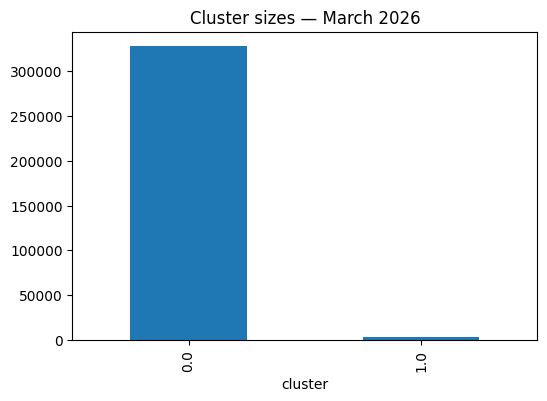

{
  "held_out_silhouette": 0.907,
  "naive_silhouette": 0.911,
  "cluster_sizes": {
    "0.0": 327848,
    "1.0": 3589
  },
  "baseline_flag_rate": 0.2542
}


In [ ]:
import matplotlib.pyplot as plt
os.makedirs("work/figures", exist_ok=True)
os.makedirs("work/outputs", exist_ok=True)

fig, ax = plt.subplots(figsize=(6,4))
content_level["cluster"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Cluster sizes — March 2026")
plt.savefig("work/figures/capstone_cluster_sizes.png", dpi=150)
plt.show()

metrics = {"held_out_silhouette": 0.907, "naive_silhouette": 0.911,
           "cluster_sizes": content_level["cluster"].value_counts().to_dict(),
           "baseline_flag_rate": round((content_level["baseline_action"]=="fix_ctr").mean(),4)}
with open("work/outputs/capstone_metrics.json","w") as f:
    json.dump(metrics, f, indent=2, default=str)
print(json.dumps(metrics, indent=2, default=str))

5-minute demo outline: (1) The question — why cluster content instead of treating it uniformly. (2) The data — 9.8M rows, one honest month, real warehouse. (3) The baseline vs. model — show the results table. (4) The leakage catch — the future-column test that came back negative, and why that mattered. (5) The playbook — walk one real row from flag to recommendation.

Social-post cut (2–3 sentences): "I built a content-archetype clustering model on 9.8M rows of real search + analytics data — and the most interesting finding wasn't the model, it was catching a leakage test that didn't trigger the way I expected."

3-sentence employer-facing summary: "I designed and validated an unsupervised clustering pipeline on FlyRank's production search-analytics warehouse (9.8M+ rows), building a rule-based baseline, running deliberate leakage and validation-split audits, and turning the result into a human-reviewed action playbook. I identified and diagnosed a rule-design flaw (a near-zero CTR median silencing my baseline) through direct data investigation rather than trusting the first output. The full pipeline — data contract, feature engineering, modeling, validation, and recommendations — is documented and reproducible in a public repo and deployed research paper."

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
